# Fake News Detection using Machine Learning

## Objective
The objective of this project is to build a machine learning model that classifies news articles as **Real** or **Fake** using Natural Language Processing (NLP) techniques.

## Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn

## Dataset
- Fake and Real News Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import pickle

## Load the Dataset

The dataset contains two CSV files:

- Fake.csv
- True.csv

Each file contains news articles that will be used for training the classification model.

In [6]:
fake = pd.read_csv("Fake.csv", engine='python', on_bad_lines='skip')
true = pd.read_csv("True.csv", engine='python', on_bad_lines='skip')

In [7]:
fake["label"] = 0
true["label"] = 1

In [8]:
data = pd.concat([fake, true], ignore_index=True)

In [9]:
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

In [10]:
data.head()

,title,text,subject,date,label
0,"Manafort, ex-associate face charges in U.S. Ru...",WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"October 30, 2017",1
1,Airlines in Cairo asked to implement Trump tra...,CAIRO (Reuters) - Airlines operating at Cairo ...,politicsNews,"January 29, 2017",1
2,NO MORE MR. NICE GUY: TRUMP Takes Off The Glov...,Last December a report surfaced that Barack Ob...,politics,"Dec 28, 2016",0
3,Trump to fundraise for campaign if he wins Rep...,WASHINGTON (Reuters) - Republican presidential...,politicsNews,"March 3, 2016",1
4,Graft probe into Mexico president's ally poses...,MEXICO CITY (Reuters) - With a tight general e...,worldnews,"October 21, 2017",1


In [11]:
print("Dataset Shape:", data.shape)
print()

data.info()

Dataset Shape: (34156, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34156 entries, 0 to 34155
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    34156 non-null  object
 1   text     34156 non-null  object
 2   subject  34156 non-null  object
 3   date     34156 non-null  object
 4   label    34156 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.3+ MB


In [12]:
data.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [13]:
data["label"].value_counts()

,count
label,
1,17370
0,16786


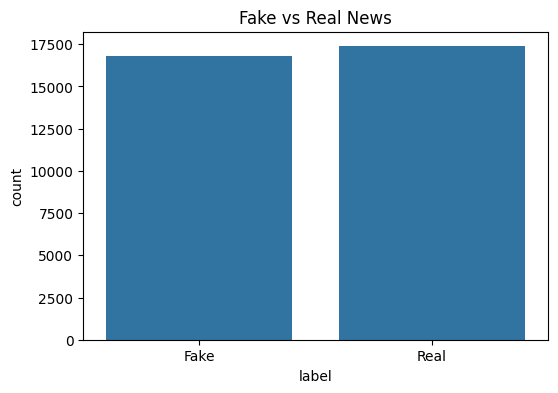

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x=data["label"])

plt.xticks([0,1],["Fake","Real"])
plt.title("Fake vs Real News")

plt.show()

## Data Preprocessing

For this project, the **title** of each news article is used as the input feature. The text is converted into numerical features using the TF-IDF Vectorizer, which captures the importance of words while reducing the influence of very common terms.

In [15]:
X = data["title"]
y = data["label"]

## Split the Dataset

The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 27324
Testing Samples: 6832


## TF-IDF Vectorization

The text data is converted into numerical vectors using the TF-IDF (Term Frequency–Inverse Document Frequency) technique, allowing machine learning algorithms to process textual information.

In [17]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## Train the Machine Learning Model

A Logistic Regression classifier is trained using the TF-IDF features to classify news articles as either Fake or Real.

In [18]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [19]:
y_pred = model.predict(X_test_tfidf)

In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 94.31 %


## Model Evaluation

The trained model is evaluated using accuracy, a confusion matrix, and a classification report to measure its performance on the test dataset.

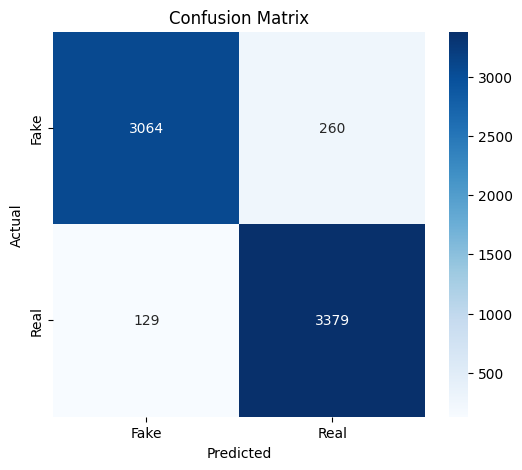

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake","Real"],
            yticklabels=["Fake","Real"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94      3324
           1       0.93      0.96      0.95      3508

    accuracy                           0.94      6832
   macro avg       0.94      0.94      0.94      6832
weighted avg       0.94      0.94      0.94      6832



## Sample Predictions

The trained model is used to predict whether selected news headlines are **Fake** or **Real**.

In [23]:
sample_news = [
    "NASA announces successful mission to Mars.",
    "Aliens have landed and taken over New York City."
]

sample_tfidf = vectorizer.transform(sample_news)
predictions = model.predict(sample_tfidf)

for news, pred in zip(sample_news, predictions):
    label = "Real" if pred == 1 else "Fake"
    print(f"News: {news}")
    print(f"Prediction: {label}\n")

News: NASA announces successful mission to Mars.
Prediction: Real

News: Aliens have landed and taken over New York City.
Prediction: Real



## Save the Model

The trained Logistic Regression model and TF-IDF vectorizer are saved for future use.

In [24]:
with open("fake_news_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


# Conclusion

In this project, a Fake News Detection system was developed using Natural Language Processing (NLP) and Machine Learning. The news headlines were transformed into numerical features using TF-IDF Vectorization, and a Logistic Regression classifier was trained to distinguish between fake and real news articles.

The trained model achieved high accuracy on the test dataset, demonstrating that machine learning can effectively classify news articles based on textual content.